In [1]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv(
    "../data/raw/spy.csv",
    index_col="Date",
    parse_dates=True
)

data.head()

,Close,High,Low,Open,Volume
Date,,,,,
2004-01-02,73.461731,74.095761,73.131507,73.798556,38072300
2004-01-05,74.260887,74.313719,73.699501,73.765550,27959800
2004-01-06,74.333511,74.452392,73.970263,74.075937,20472800
2004-01-07,74.584496,74.670352,73.897628,74.227853,30170400
2004-01-08,74.881721,74.901539,74.478847,74.795865,36438400


In [2]:
data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 5535 entries, 2004-01-02 to 2025-12-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   5535 non-null   float64
 1   High    5535 non-null   float64
 2   Low     5535 non-null   float64
 3   Open    5535 non-null   float64
 4   Volume  5535 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 259.5 KB


In [3]:
data.isna().sum()

Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

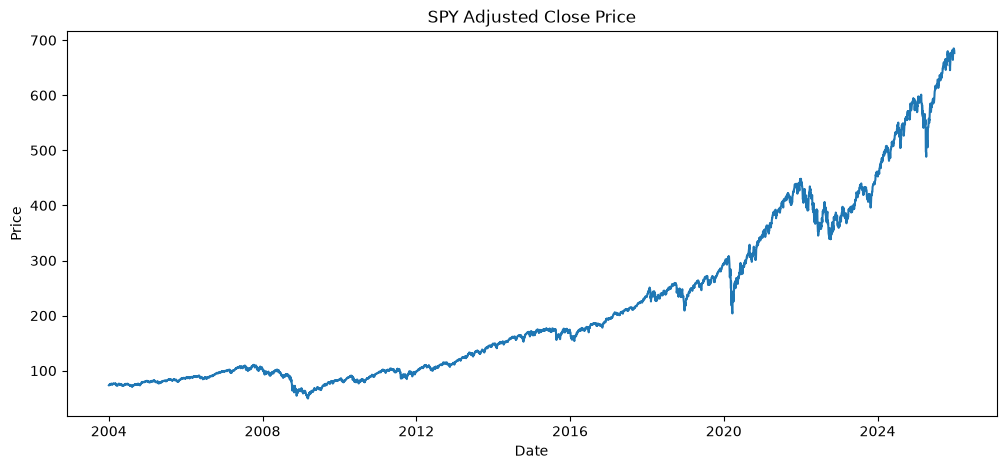

In [4]:
plt.figure(figsize=(12,5))

plt.plot(data.index, data["Close"])

plt.title("SPY Adjusted Close Price")
plt.xlabel("Date")
plt.ylabel("Price")

plt.show()

In [5]:
data["return"] = data["Close"].pct_change()

In [6]:
data.head()

,Close,High,Low,Open,Volume,return
Date,,,,,,
2004-01-02,73.461731,74.095761,73.131507,73.798556,38072300,NaN
2004-01-05,74.260887,74.313719,73.699501,73.765550,27959800,0.010879
2004-01-06,74.333511,74.452392,73.970263,74.075937,20472800,0.000978
2004-01-07,74.584496,74.670352,73.897628,74.227853,30170400,0.003376
2004-01-08,74.881721,74.901539,74.478847,74.795865,36438400,0.003985


In [7]:
import numpy as np

data["log_return"] = np.log(
    data["Close"] / data["Close"].shift(1)
)

In [8]:
data.head()

,Close,High,Low,Open,Volume,return,log_return
Date,,,,,,,
2004-01-02,73.461731,74.095761,73.131507,73.798556,38072300,NaN,NaN
2004-01-05,74.260887,74.313719,73.699501,73.765550,27959800,0.010879,0.010820
2004-01-06,74.333511,74.452392,73.970263,74.075937,20472800,0.000978,0.000977
2004-01-07,74.584496,74.670352,73.897628,74.227853,30170400,0.003376,0.003371
2004-01-08,74.881721,74.901539,74.478847,74.795865,36438400,0.003985,0.003977


In [9]:
data["log_return"].describe()

count    5534.000000
mean        0.000401
std         0.011830
min        -0.115886
25%        -0.003939
50%         0.000727
75%         0.005752
max         0.135578
Name: log_return, dtype: float64

In [10]:
daily_vol = data["log_return"].std()

daily_vol

np.float64(0.011830220527261797)

In [11]:
annual_vol = daily_vol * np.sqrt(252)

annual_vol

np.float64(0.18779892882111682)

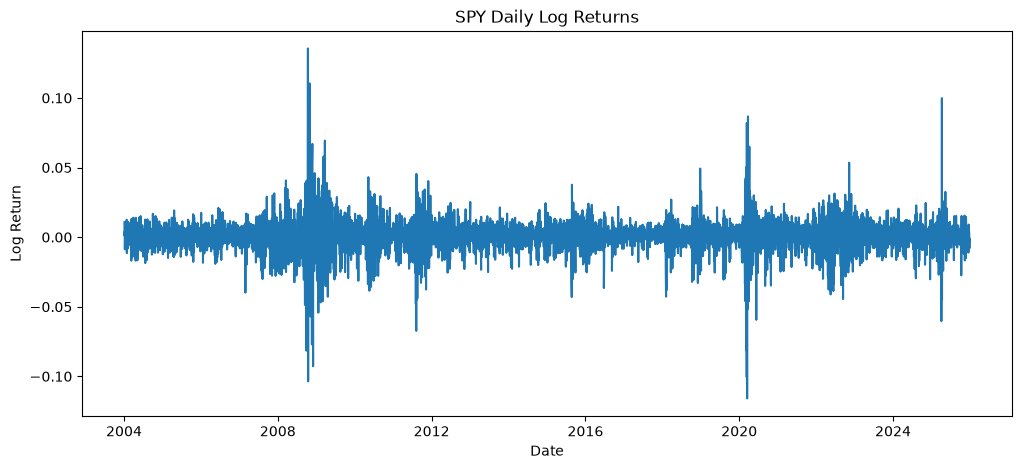

In [12]:
plt.figure(figsize=(12,5))
plt.plot(
    data.index,
    data["log_return"]
)

plt.title("SPY Daily Log Returns")
plt.xlabel("Date")
plt.ylabel("Log Return")

plt.show()

In [13]:
TRADING_DAYS = 252
ROLLING_WINDOW = 20

data["rolling_vol_20"] = (
    data["log_return"]
    .rolling(window=ROLLING_WINDOW)
    .std()
    * np.sqrt(TRADING_DAYS)
)

data[["log_return", "rolling_vol_20"]].head(25)

,log_return,rolling_vol_20
Date,,
2004-01-02,NaN,NaN
2004-01-05,0.010820,NaN
2004-01-06,0.000977,NaN
2004-01-07,0.003371,NaN
2004-01-08,0.003977,NaN
2004-01-09,-0.008770,NaN
2004-01-12,0.007358,NaN
2004-01-13,-0.005847,NaN
2004-01-14,0.008317,NaN


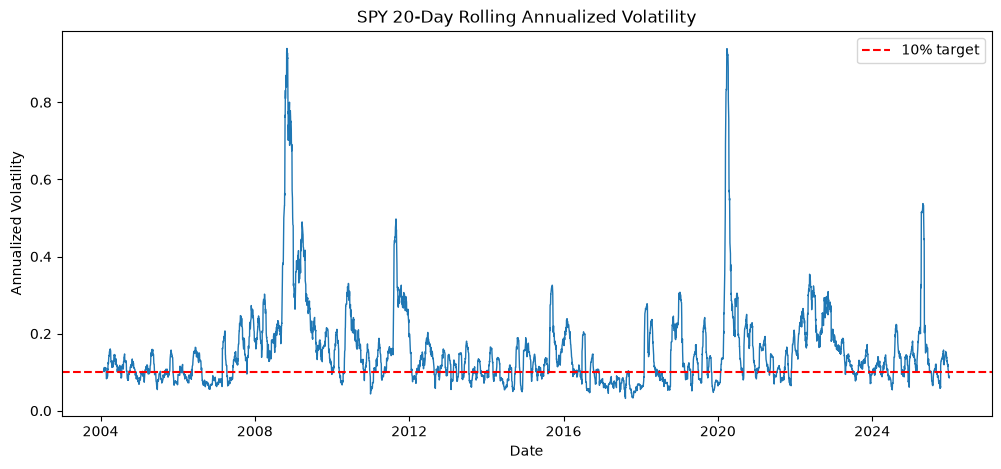

In [14]:
plt.figure(figsize=(12, 5))

plt.plot(
    data.index,
    data["rolling_vol_20"],
    linewidth=1,
)

plt.axhline(
    0.10,
    color="red",
    linestyle="--",
    label="10% target",
)

plt.title("SPY 20-Day Rolling Annualized Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.show()

In [15]:
data["rolling_vol_20"].describe()

count    5515.000000
mean        0.154698
std         0.109154
min         0.031859
25%         0.092630
50%         0.126371
75%         0.180521
max         0.939715
Name: rolling_vol_20, dtype: float64

In [16]:
max_vol_date = data["rolling_vol_20"].idxmax()
max_vol = data.loc[max_vol_date, "rolling_vol_20"]

print(f"Maximum volatility date: {max_vol_date.date()}")
print(f"Maximum annualized volatility: {max_vol:.2%}")

Maximum volatility date: 2008-10-31
Maximum annualized volatility: 93.97%


In [17]:
EWMA_LAMBDA = 0.94

squared_returns = data["log_return"] ** 2

data["ewma_variance"] = squared_returns.ewm(
    alpha=1 - EWMA_LAMBDA,
    adjust=False,
).mean()

data["ewma_vol"] = (
    np.sqrt(data["ewma_variance"])
    * np.sqrt(TRADING_DAYS)
)

data[["log_return", "rolling_vol_20", "ewma_vol"]].tail()

,log_return,rolling_vol_20,ewma_vol
Date,,,
2025-12-24,0.003511,0.089406,0.112382
2025-12-26,-0.000101,0.087001,0.108959
2025-12-29,-0.003570,0.086672,0.106548
2025-12-30,-0.001222,0.084880,0.103412
2025-12-31,-0.007436,0.089405,0.104348


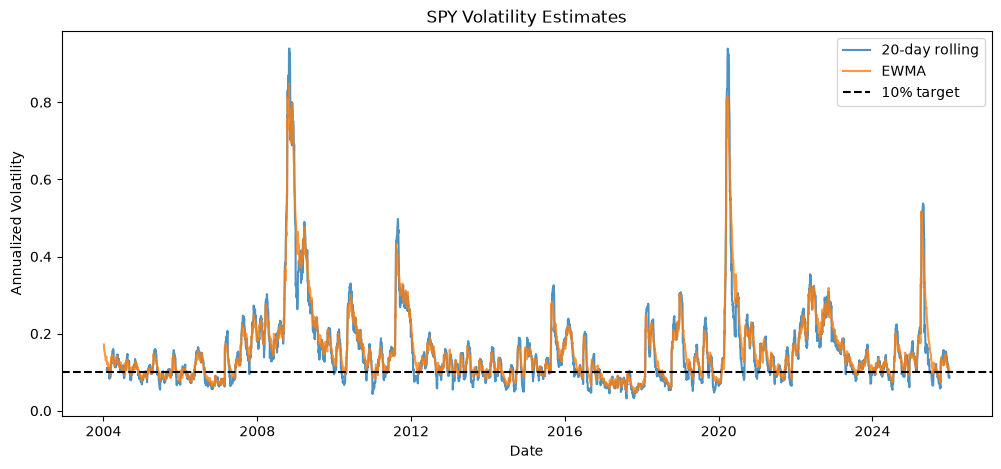

In [18]:
plt.figure(figsize=(12, 5))

plt.plot(
    data.index,
    data["rolling_vol_20"],
    label="20-day rolling",
    alpha=0.8,
)

plt.plot(
    data.index,
    data["ewma_vol"],
    label="EWMA",
    alpha=0.8,
)

plt.axhline(
    0.10,
    color="black",
    linestyle="--",
    label="10% target",
)

plt.title("SPY Volatility Estimates")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.show()

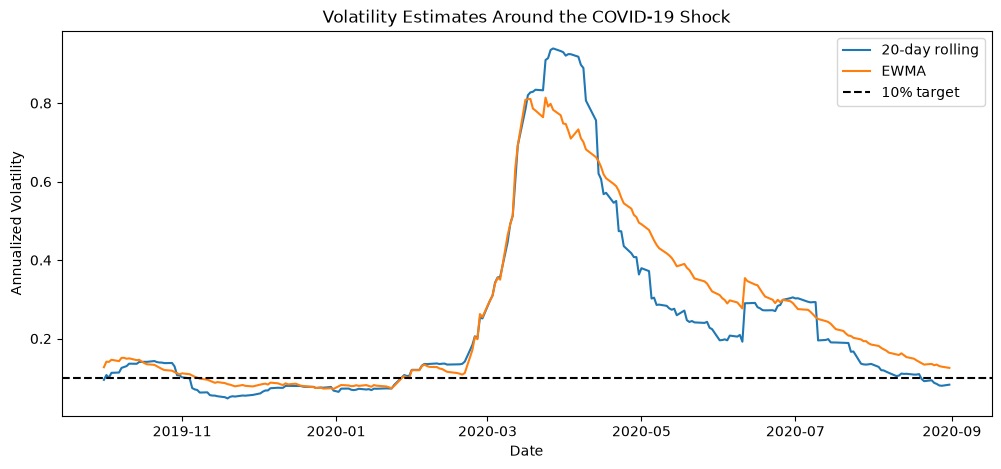

In [20]:
covid_period = data.loc[
    "2019-10-01":"2020-08-31"
]

plt.figure(figsize=(12, 5))

plt.plot(
    covid_period.index,
    covid_period["rolling_vol_20"],
    label="20-day rolling",
)

plt.plot(
    covid_period.index,
    covid_period["ewma_vol"],
    label="EWMA",
)

plt.axhline(
    0.10,
    color="black",
    linestyle="--",
    label="10% target",
)

plt.title("Volatility Estimates Around the COVID-19 Shock")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.show()

In [21]:
for column in ["rolling_vol_20", "ewma_vol"]:
    max_date = data[column].idxmax()
    max_value = data.loc[max_date, column]

    print(
        f"{column}: "
        f"{max_value:.2%} on {max_date.date()}"
    )

rolling_vol_20: 93.97% on 2008-10-31
ewma_vol: 84.77% on 2008-10-28


In [23]:
comparison = data.loc[
    "2020-02-15":"2020-04-30",
    ["log_return", "rolling_vol_20", "ewma_vol"],
]

comparison_percent = comparison * 100
comparison_percent.tail(20).round(2)

,log_return,rolling_vol_20,ewma_vol
Date,,,
2020-04-02,2.28,92.48,72.96
2020-04-03,-1.46,92.46,70.96
2020-04-06,6.50,91.81,73.29
2020-04-07,0.10,89.76,71.06
2020-04-08,3.30,88.94,70.08
2020-04-09,1.51,80.65,68.20
2020-04-13,-0.92,75.59,66.22
2020-04-14,2.91,62.04,65.19
2020-04-15,-2.15,60.64,63.75
